<a href="https://colab.research.google.com/github/adas754/ann_class/blob/main/arima.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# What is Time Series?
* Across industries, organizations commonly use time series data, which refers to any information collected over a regular interval of time in their operations. Examples include daily stock prices, energy consumption rates, social media engagement metrics, and retail demand among others. Analyzing time series data yields insights like trends, seasonal patterns and forecasts into future events that can help generate profits. For example, by understanding the seasonal trends in demand for retail products, companies can plan promotions to maximize sales throughout the year.
* There are multiple time series algorithms that are optimized for forecasting continuous values, such as temperature or product sales. A time series model can predict trends based only on the original dataset collected over a period of time.

**White noise**
* A time series is white noise if the variables are independent and identically distributed with a mean of zero. This means that all variables have the same variance (sigma^2) and each value has a zero correlation with all other values in the series.


**Data patterns**

**cycle**
* A cyclic pattern occurs when data rise and fall, but this does not happen within the fixed time and the duration of these fluctuations is usually at least 2 years
![](cycle.png)

**Trend**
* A trend pattern exists when there is a long-term increase or decrease in the series. The trend can be linear, exponential
![](trend.png)

**Seasonal**
* Seasonality exists when data is influenced by seasonal factors, such as a day of the week, a month, and one-quarter of the year. A seasonal pattern exists of a fixed known period.
![](sea.png)

**Random**
* which do not follow any trend, cycle or seasonal patterns
![](ran.png)


**Types**
* Types of time series models are moving average, ARIMA etc.The crucial thing is to choose the right forecasting method as per the characteristics of the time series data. The following are some of the basic time series models:



**MA(Moving Average)**
* A moving average is defined as an average of fixed number of items in the time series which move through the series by dropping the top items of the previous averaged group and adding the next in each successive average.
Yt depends only on random error terms
     	Yt = f( εt, εt-1, εt-2, εt-3, ..)
		or
 	Yt = β + εt + θ1 εt-1 + θ2εt-2 + θ3 εt-3 +…



**AR(Auto Regressive)**
* Autoregression is a time series model that uses observations from previous time steps as input to a regression equation to predict the value at the next time step. It is a very simple idea that can result in accurate forecasts on a range of time series problems.
* Yt depends only of past values.
* Yt-1, Yt-2, Yt-3 etc
              * Yt  = f(Yt-1, Yt-2, Yt-3… )
              * Yt = β0 + β1Yt-1 + β2Yt-2 + β3Yt-3 …


**ARMA**
* Time series, autoregressive–moving-average (ARMA) models provide a parsimonious description of a (weakly) stationary stochastic process in terms of two polynomials, one for the autoregression (AR) and the second for the moving average (MA).
* Combines AR and MA
	* Yt = β0 + β1Yt-1 + β2Yt-2 + β3Yt-3 …εt + θ1 εt-1 + θ2εt-2 + θ3 εt-3 +…


**ARIMA**
* Autoregressive Integrated Moving Average (ARIMA) model is another widely used forecasting technique that involves the combination of two or more time series models. This model is suitable for multivariate non-stationary data. ARIMA method is based on the concepts of autoregression, autocorrelation, and moving average.






### Create a Time Series Model to predict the future air passenger traffic

In [1]:
# Import the Pandas library for data manipulation and analysis
import pandas as pd

# Import the NumPy library for numerical and mathematical operations
import numpy as np

# Import the warnings module to manage warning messages
import warnings

# Ignore all warning messages to keep the output clean
warnings.filterwarnings('ignore')

In [3]:
## loading the data
data=pd.read_csv('/content/AirPassengers.csv')
# we have data of airline passengers travelled between January 1949 and December 1960

In [4]:
data.head()#first five rows

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [6]:
data['#Passengers'].max()

622

In [7]:
data.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [9]:
data['#Passengers'].min()

104

In [12]:
data.info()#info about datatype and null value

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   #Passengers  144 non-null    int64
dtypes: int64(1)
memory usage: 2.2 KB


In [ ]:
# Month is actually given as string here. It must be in date-time format

In [10]:
## parse_dates: parsing the date (Converts the string representation of a date to Date object)
# index_col: using date column as index

data=pd.read_csv('AirPassengers.csv',parse_dates=[0],index_col='Month')

In [14]:
data

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   #Passengers  144 non-null    int64
dtypes: int64(1)
memory usage: 2.2 KB


# Basic checks

In [16]:
data.head()#first five rows

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [17]:
data.rename(columns = {'#Passengers': 'Passengers'}, inplace = True)

In [19]:
data['Passengers']

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


In [20]:
data.describe()##used to view some basic statistical details like percentile, mean, std etc.

,Passengers
count,144.000000
mean,280.298611
std,119.966317
min,104.000000
25%,180.000000
50%,265.500000
75%,360.500000
max,622.000000


# EDA

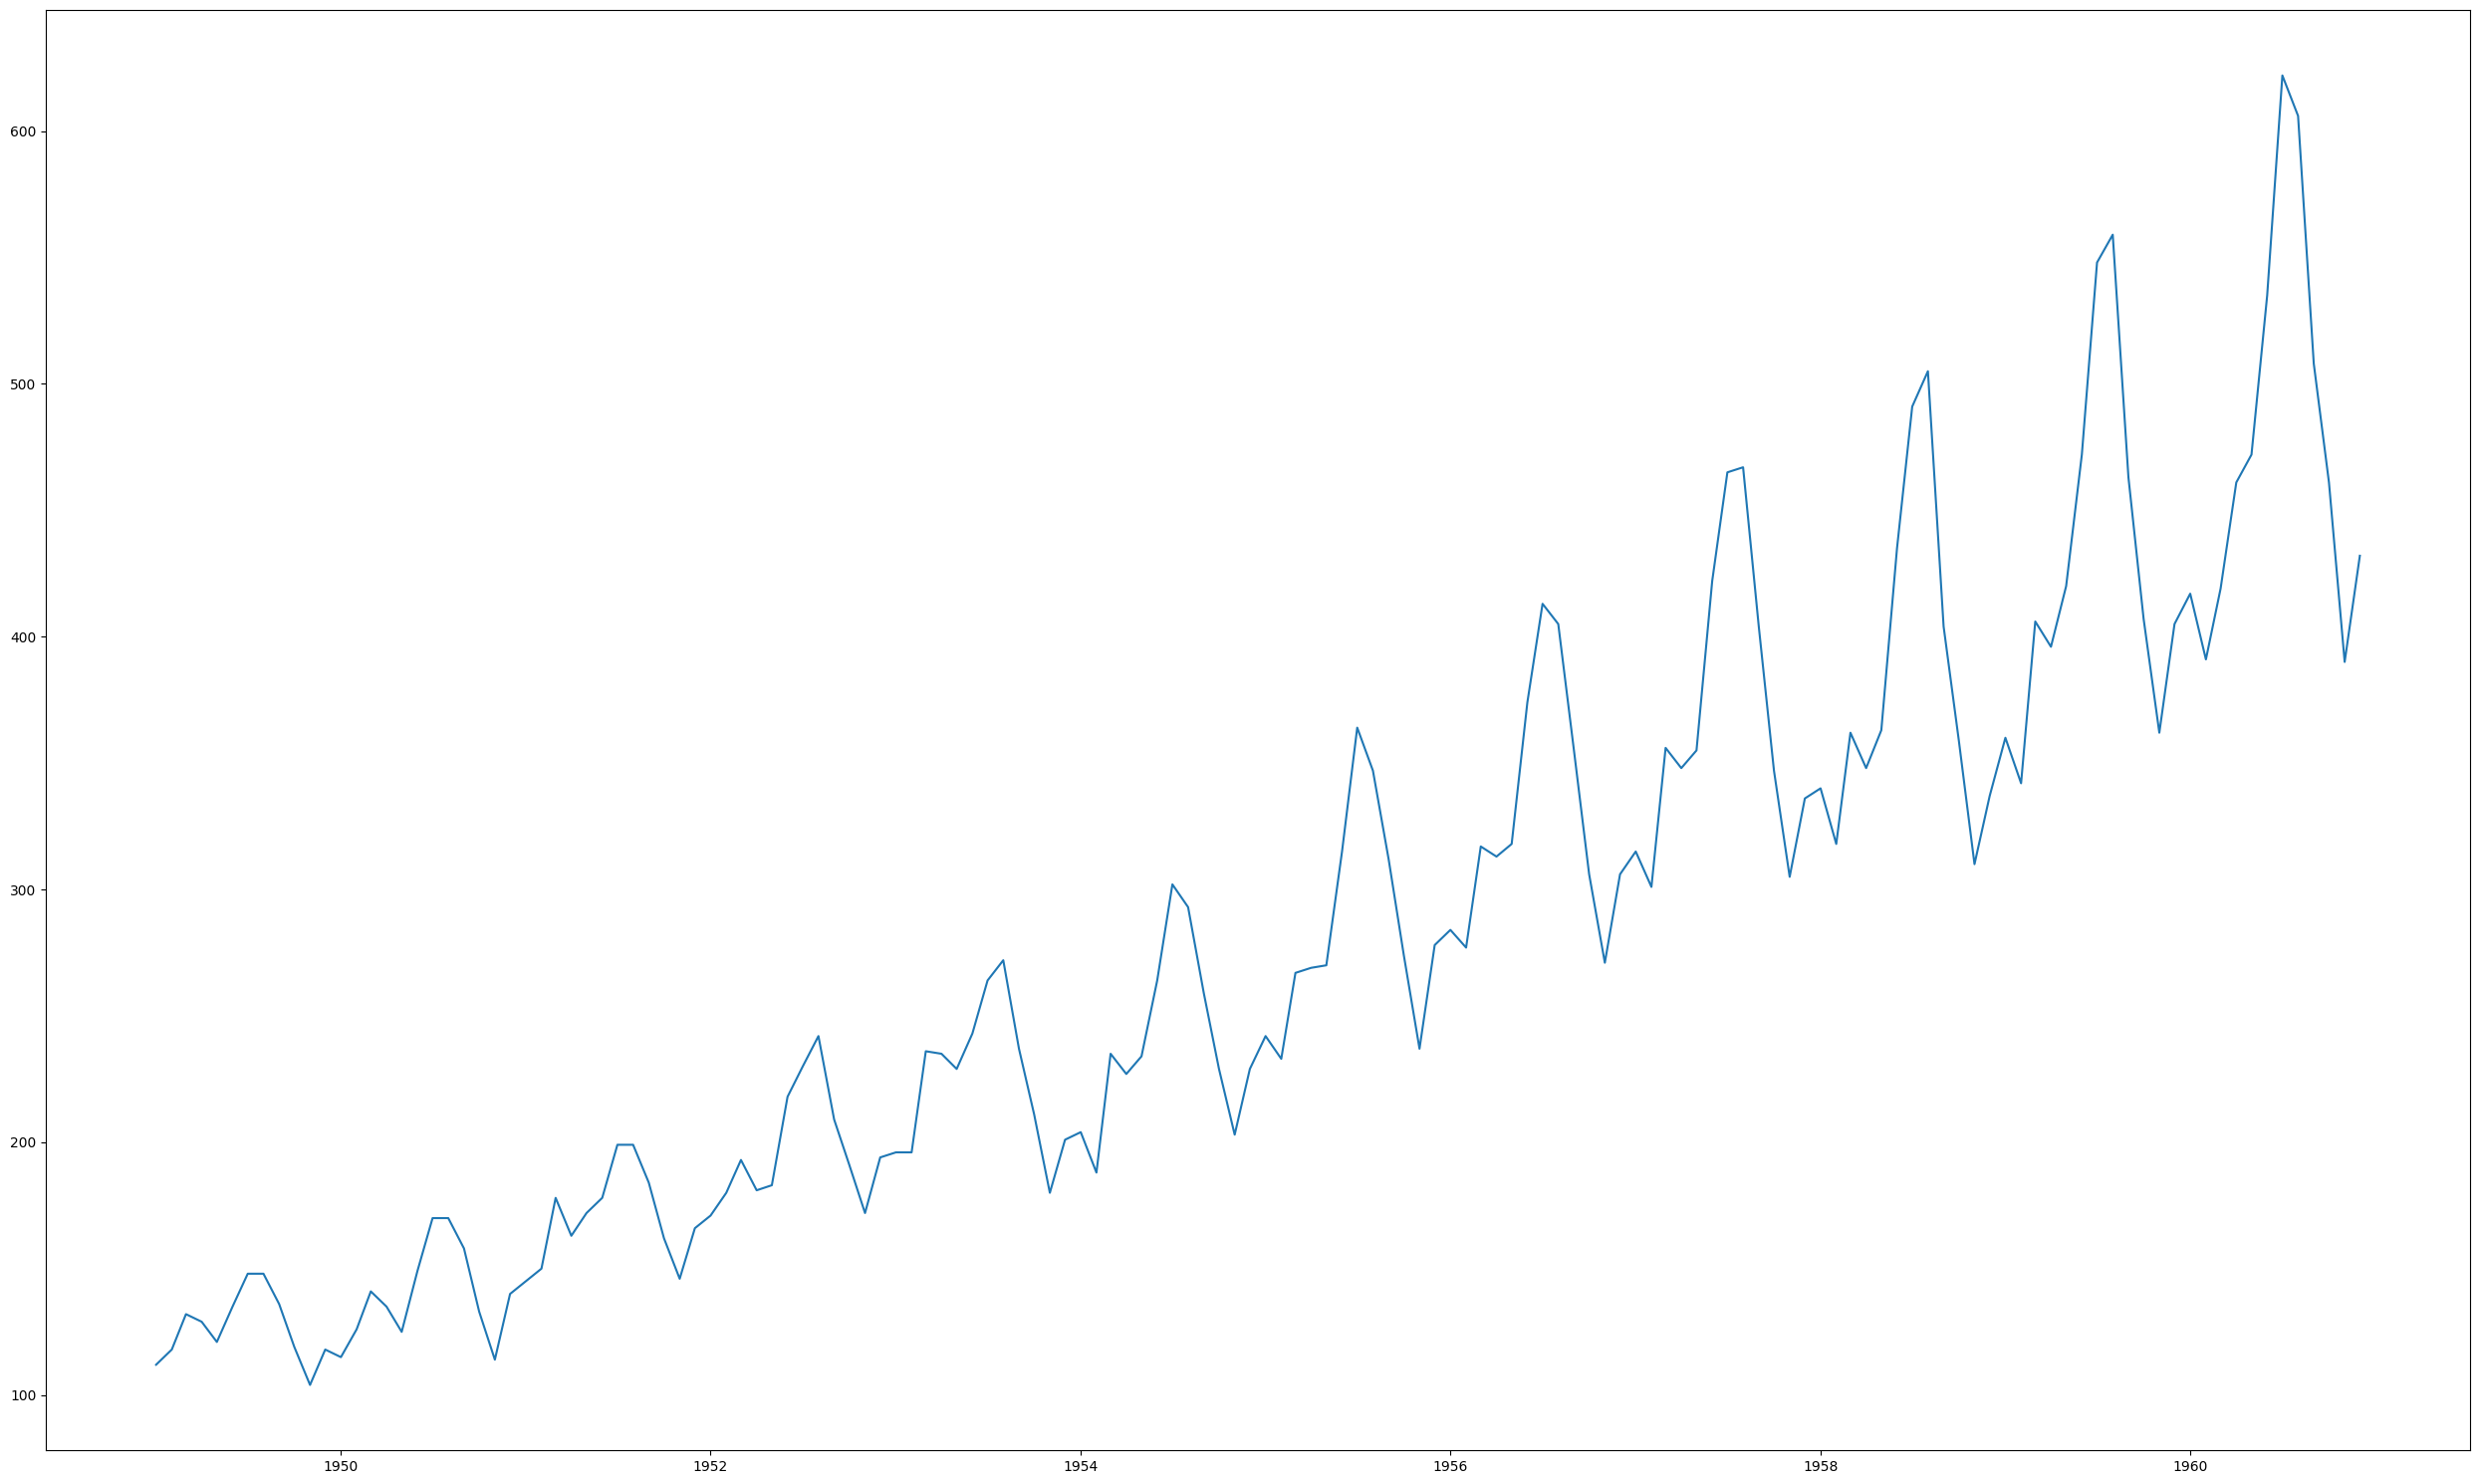

In [21]:
# Import the pyplot module from Matplotlib for creating graphs and visualizations
import matplotlib.pyplot as plt

# Create a figure (canvas) with a width of 25 inches, height of 15 inches, and a white background
plt.figure(figsize=(25,15), facecolor='white')

# Plot the 'Passengers' column from the dataset as a line graph
plt.plot(data['Passengers'])

# Automatically adjust the spacing so that all plot elements fit properly
plt.tight_layout()

# From the plot, we can observe that the time series is not stationary
# (its mean and variance change over time)

## Stationarity

* Stationarity means that the statistical properties of a time series (or rather the process generating it) do not change over time.
* Stationarity is important because many useful analytical tools and statistical tests and models rely on it.

* Constant mean
* Constant variance
* Constant covariance between periods of identical distance

* All it states is that the covariance between time periods of identical lengths (let’s say 10 days/hours/minutes) should be identical to the covariance of some other period of the same length:

![image-2.png](attachment:image-2.png)



**Why do we need Stationarity?**
- Stationary processes are easier to analyze
- Stationarity is assumed by most of the algorithms
- It is essential to remove any trend or seasonality before modeling the time series data because if the statistical properties do not change over time, it is easier to model the data accurately. One of the popular ways of making the series stationary is differencing.

**How to check if given series is stationary or not:**
- One way is to check autocorrelation.
- Autocorrelation is the similarity between observations as a function of the time lag between them.

* When plotting the value of the ACF for increasing lags (a plot called a correlogram), the values tend to degrade to zero quickly for stationary time series, while for non-stationary data the degradation will happen more slowly.

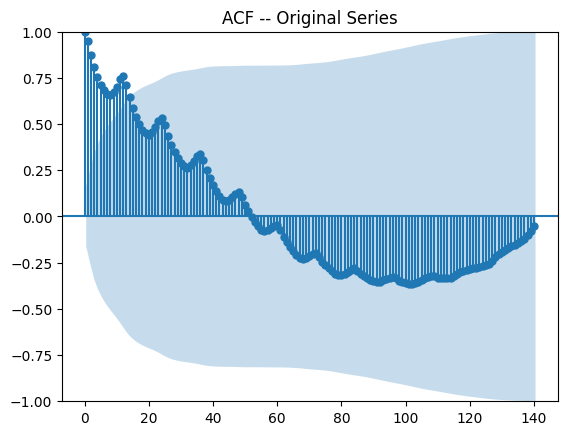

In [23]:
# Import the function to plot the AutoCorrelation Function (ACF)
from statsmodels.graphics.tsaplots import plot_acf

# Plot the ACF of the dataset up to 140 lag values
plot_acf(data, lags=140)

# Add a title to the ACF plot
plt.title('ACF -- Original Series')

# Display the plot on the screen
plt.show()

# Plot the ACF using only 15 lags (may not show the seasonal pattern at lag 12)
# plot_acf(data1, lags=15)

# Plot the ACF using 40 lags to clearly observe the seasonal spike at lag 12
# plot_acf(data1, lags=40)

### Making the Series Stationary: Differencing

Subtract each value from the previous one:

$$y'_t = y_t - y_{t-1}$$

Apply again if still non-stationary. The number of times we difference = **d** in ARIMA(p, **d**, q).

In [24]:
# Make the time series stationary by taking the first difference
data1 = data.diff(periods=1)

# The diff() function subtracts the previous value from the current value
# (Current Value - Previous Value)

# Display the first 5 rows of the new differenced dataset
data1.head()

,Passengers
Month,
1949-01-01,NaN
1949-02-01,6.0
1949-03-01,14.0
1949-04-01,-3.0
1949-05-01,-8.0


In [25]:
# Remove the first row containing the NaN value
data1 = data1.iloc[1:] #ARIMA cannot train on missing (NaN) values.

# Display the first 5 rows of the cleaned dataset
data1.head()

,Passengers
Month,
1949-02-01,6.0
1949-03-01,14.0
1949-04-01,-3.0
1949-05-01,-8.0
1949-06-01,14.0


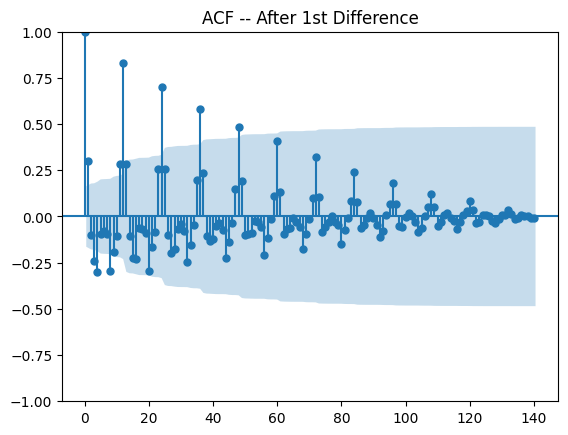

In [26]:
# Plot the AutoCorrelation Function (ACF) of the first-order differenced data
plot_acf(data1, lags=140)

# Add a title to the ACF plot
plt.title('ACF -- After 1st Difference')

# Display the ACF plot
plt.show()

In [30]:
# Apply first-order differencing again to the already differenced data
data2 = data1.diff(periods=1)

# Display the first 5 rows of the new dataset
data2.head()

,Passengers
Month,
1949-02-01,NaN
1949-03-01,8.0
1949-04-01,-17.0
1949-05-01,-5.0
1949-06-01,22.0


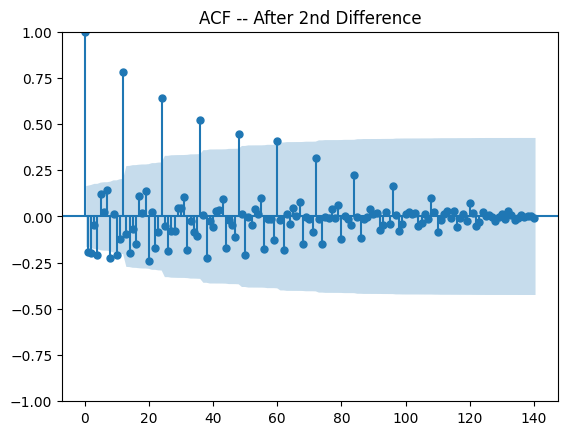

In [31]:
# Remove the first row containing the NaN value after second-order differencing
data2 = data2.iloc[1:]

# Plot the AutoCorrelation Function (ACF) of the second-order differenced data
plot_acf(data2, lags=140)

# Add a title to the ACF plot
plt.title('ACF -- After 2nd Difference')

# Display the ACF plot
plt.show()

In [33]:
# Split the data into training and testing sets
train = data2[:100]   # Use the first 100 rows for training
test = data2[100:]    # Use the remaining rows for testing

# Print the number of rows in the training and testing datasets
print(f"Train size: {len(train)}, Test size: {len(test)}")

Train size: 100, Test size: 42


[link text](https://)## AR (AutoRegressive) Model

AR predicts today's value using **past values** of the same series:

$$Y_t = c + \phi_1 Y_{t-1} + \phi_2 Y_{t-2} + \ldots + \varepsilon_t$$

We use `ar_select_order` to find the optimal lags automatically.


 (Y_t) → The current value to be predicted.

(c)→ A constant (intercept) added to the prediction.

 (ϕ) → A coefficient that determines the influence of past values.

(Y_{t-1}) → The previous observation (Lag 1).

(Y_{t-2}) → The observation from two time steps ago (Lag 2).

 (\epsilon_t) → The random error (noise) that the model cannot explain.



[link text](https://)## AR (AutoRegressive) Model

AR predicts today's value using **past values** of the same series:

$$Y_t = c + \phi_1 Y_{t-1} + \phi_2 Y_{t-2} + \ldots + \varepsilon_t$$

We use `ar_select_order` to find the optimal lags automatically.

In [ ]:
pip install statsmodels

In [34]:
# Import the AutoReg class to build an Autoregressive (AR) model
from statsmodels.tsa.ar_model import AutoReg

# Import the warnings module
import warnings

# Ignore warning messages to keep the output clean
warnings.filterwarnings('ignore')

In [37]:
# Import the function to find the best lag values for the AR model
from statsmodels.tsa.ar_model import ar_select_order

# Find the best combination of lags (up to 15 lags)
mod = ar_select_order(data1, maxlag=15, glob=True)

# Display the selected lag values
mod.ar_lags

[1, 8, 12, 13]

In [38]:
# Create an AutoReg (AR) model using the selected lag values
ar_model = AutoReg(train, lags=[1, 8, 12, 13])

# Train (fit) the AR model using the training data
ar_model_fit = ar_model.fit()

# Predict values from index 100 to 142
prediction = ar_model_fit.predict(start=100, end=142)

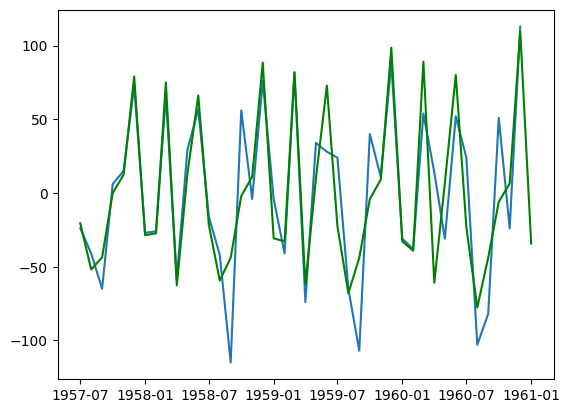

In [39]:
# Import the pyplot module for creating graphs
import matplotlib.pyplot as plt

# Plot the actual values from the test dataset
plt.plot(test)

# Plot the predicted values in green for comparison
plt.plot(prediction, color='green')

## ARIMA Model

In [40]:
# Import the ARIMA class for building an ARIMA time series forecasting model
from statsmodels.tsa.arima.model import ARIMA

In [43]:
# Create an ARIMA model with order (1, 1, 0)
model_arima = ARIMA(train, order=(1,1,0))

# Train (fit) the ARIMA model using the training data
model_arima_fit = model_arima.fit()

# Print the AIC value of the trained ARIMA model
print(f"ARIMA(1,1,0) AIC: {model_arima_fit.aic:.2f}")

ARIMA(1,1,0) AIC: 1021.04


# Akaike Information Criteria (AIC):

AIC is an estimator of prediction error which measures a statistical model in order to quantify the goodness of fit of the model. While comparing two models, the smaller the AIC value, the better the time series model.

![image.png](attachment:image.png)
K: The number of model parameters.
ln(L): The log-likelihood of the model. This tells us how likely the model is, given the data.


AIC uses a model’s maximum likelihood estimation (log-likelihood) as a measure of fit. Log-likelihood is a measure of how likely one is to see their observed data, given a model. The model with the maximum likelihood is the one that “fits” the data the best. The natural log of the likelihood is used as a computational convenience.

AIC is low for models with high log-likelihoods. This means the model fits the data better, which is what we want.

Once you’ve fit several regression models, you can compare the AIC value of each model. The model with the lowest AIC offers the best fit.

There is no value for AIC that can be considered “good” or “bad” because we simply use AIC as a way to compare regression models. The model with the lowest AIC offers the best fit. The absolute value of the AIC value is not important.

### Finding the Best (p, d, q) Using AIC

Try all combinations of p, d, q from 0 to 3 and pick the one with the **lowest AIC**.

In [45]:
# Import the itertools module to generate all combinations of values
import itertools

# Define the range of values for p, d, and q (0 to 3)
p = d = q = range(0, 4)

# Generate all possible combinations of (p, d, q)
pdq = list(itertools.product(p, d, q))

# Display all generated (p, d, q) combinations
pdq

[(0, 0, 0),
 (0, 0, 1),
 (0, 0, 2),
 (0, 0, 3),
 (0, 1, 0),
 (0, 1, 1),
 (0, 1, 2),
 (0, 1, 3),
 (0, 2, 0),
 (0, 2, 1),
 (0, 2, 2),
 (0, 2, 3),
 (0, 3, 0),
 (0, 3, 1),
 (0, 3, 2),
 (0, 3, 3),
 (1, 0, 0),
 (1, 0, 1),
 (1, 0, 2),
 (1, 0, 3),
 (1, 1, 0),
 (1, 1, 1),
 (1, 1, 2),
 (1, 1, 3),
 (1, 2, 0),
 (1, 2, 1),
 (1, 2, 2),
 (1, 2, 3),
 (1, 3, 0),
 (1, 3, 1),
 (1, 3, 2),
 (1, 3, 3),
 (2, 0, 0),
 (2, 0, 1),
 (2, 0, 2),
 (2, 0, 3),
 (2, 1, 0),
 (2, 1, 1),
 (2, 1, 2),
 (2, 1, 3),
 (2, 2, 0),
 (2, 2, 1),
 (2, 2, 2),
 (2, 2, 3),
 (2, 3, 0),
 (2, 3, 1),
 (2, 3, 2),
 (2, 3, 3),
 (3, 0, 0),
 (3, 0, 1),
 (3, 0, 2),
 (3, 0, 3),
 (3, 1, 0),
 (3, 1, 1),
 (3, 1, 2),
 (3, 1, 3),
 (3, 2, 0),
 (3, 2, 1),
 (3, 2, 2),
 (3, 2, 3),
 (3, 3, 0),
 (3, 3, 1),
 (3, 3, 2),
 (3, 3, 3)]

In [46]:
# Print the total number of (p, d, q) combinations
print(f"Total combinations to try: {len(pdq)}")

Total combinations to try: 64


p is the number of previous observations (lags) used to predict the current value.

d is the number of times we difference the data to make it stationary.

q is the number of previous forecast errors used to predict the current value.

In [47]:
# Import tqdm to display a progress bar during the loop
from tqdm import tqdm

# Create an empty list to store the ARIMA parameters
list_params = []

# Create an empty list to store the AIC values
list_aic = []

# Try every (p, d, q) combination
for params in tqdm(pdq):
    try:
        # Create an ARIMA model with the current parameters
        model = ARIMA(train, order=params)

        # Train (fit) the model
        model_fit = model.fit()

        # Save the parameter combination
        list_params.append(params)

        # Save the AIC value of the model
        list_aic.append(model_fit.aic)

    # Skip combinations that cause errors
    except:
        continue

# Find the index of the model with the lowest AIC
best_idx = list_aic.index(min(list_aic))

# Get the best (p, d, q) combination
best_order = list_params[best_idx]

# Print the lowest AIC value
print(f"\nLowest AIC: {min(list_aic):.2f}")

# Print the best ARIMA order
print(f"Best order: ARIMA{best_order}")

100%|██████████| 64/64 [00:09<00:00,  6.48it/s]


Lowest AIC: 919.87
Best order: ARIMA(1, 0, 2)


In [49]:
# Create the final ARIMA model using the best (p, d, q) values
final_model = ARIMA(train, order=best_order)

# Train (fit) the final ARIMA model
final_model_fit = final_model.fit()

# Print the AIC value of the final trained model
print(f"Final model AIC: {final_model_fit.aic:.2f}")

Final model AIC: 919.87


Lowest AIC is chosen because it indicates the model that best fits the data while avoiding unnecessary complexity.

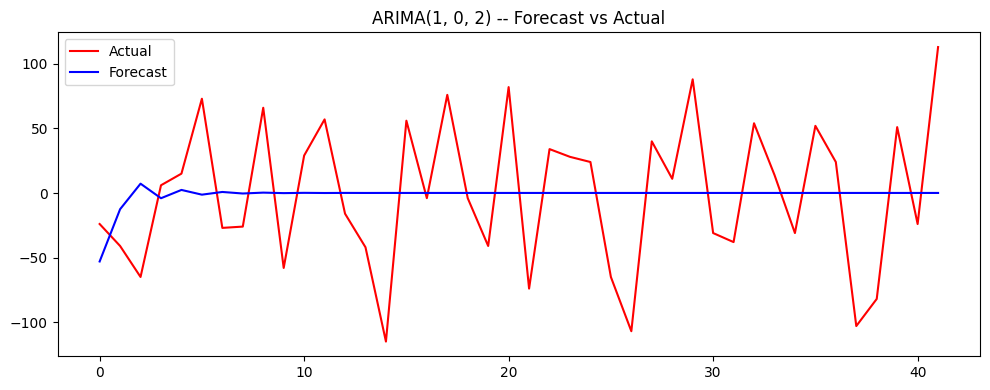

In [50]:
# Forecast the next 42 time steps using the trained ARIMA model
forecast = final_model_fit.forecast(steps=42)

# Create a new figure with a size of 10 × 4 inches
plt.figure(figsize=(10, 4))

# Plot the actual values from the test dataset in red
plt.plot(test.values, color='red', label='Actual')

# Plot the forecasted values in blue
plt.plot(forecast.values, color='blue', label='Forecast')

# Add a title showing the ARIMA model used
plt.title(f"ARIMA{best_order} -- Forecast vs Actual")

# Display the legend to identify the two lines
plt.legend()

# Adjust the layout so everything fits neatly
plt.tight_layout()

# Display the graph
plt.show()

In [51]:
# Forecast the next 25 time steps using the trained ARIMA model
forecast25 = final_model_fit.forecast(steps=25)

# Get the first 25 actual values from the test dataset
test25 = test[:25].values.flatten()

# Define a function to calculate forecast accuracy metrics
def forecast_accuracy(forecast, actual):

    # Calculate the Mean Squared Error (MSE)
    mse = np.mean((forecast - actual) ** 2)

    # Calculate the Mean Absolute Error (MAE)
    mae = np.mean(np.abs(forecast - actual))

    # Calculate the Root Mean Squared Error (RMSE)
    rmse = np.sqrt(mse)

    # Return all the metrics as a dictionary
    return {'MSE': round(mse, 4), 'MAE': round(mae, 4), 'RMSE': round(rmse, 4)}

# Calculate the accuracy metrics for the forecast
metrics = forecast_accuracy(forecast25, test25)

# Print each evaluation metric
for k, v in metrics.items():
    print(f"{k}: {v}")

MSE: 2656.5806
MAE: 43.4244
RMSE: 51.542


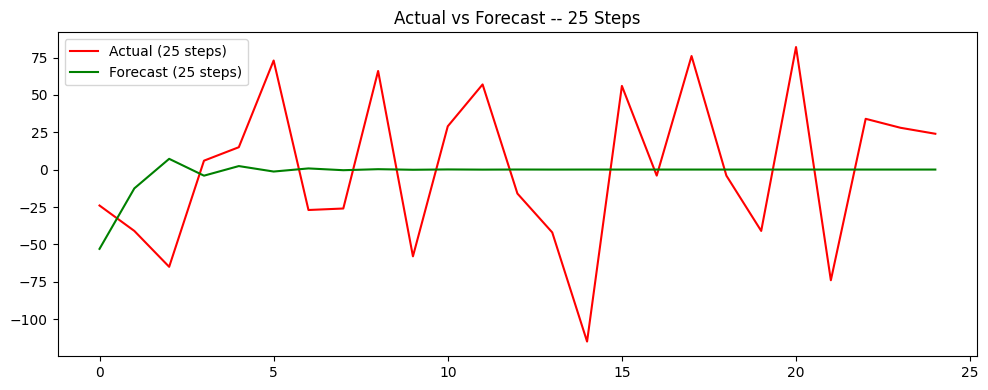

In [52]:
# Create a new figure with a size of 10 × 4 inches
plt.figure(figsize=(10, 4))

# Plot the first 25 actual values from the test dataset in red
plt.plot(test[:25].values, color='red', label='Actual (25 steps)')

# Plot the 25 forecasted values in green
plt.plot(forecast25.values, color='green', label='Forecast (25 steps)')

# Add a title to the graph
plt.title('Actual vs Forecast -- 25 Steps')

# Display the legend to identify the two lines
plt.legend()

# Adjust the layout so everything fits neatly
plt.tight_layout()

# Display the graph
plt.show()